In [2]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path("03_Customer_Churn_Prediction_and_Retention_Decision_System").resolve().parents[2]
DATA_RAW = PROJECT_ROOT / "data" / "raw"
RAW_DATA_FILE = DATA_RAW / "Telco_customer_churn.xlsx"

In [3]:
df = pd.read_excel(RAW_DATA_FILE)

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape

(7043, 33)

In [6]:
df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [7]:
clean_df = df.copy()

In [8]:
clean_df.columns = (
        clean_df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

In [9]:
clean_df.columns.tolist()

['customerid',
 'count',
 'country',
 'state',
 'city',
 'zip_code',
 'lat_long',
 'latitude',
 'longitude',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'tenure_months',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'monthly_charges',
 'total_charges',
 'churn_label',
 'churn_value',
 'churn_score',
 'cltv',
 'churn_reason']

In [10]:
missing_summary = pd.DataFrame({
        "missing_count": clean_df.isna().sum(),
        "missing_pct": (clean_df.isna().sum() / len(clean_df) * 100).round(2)
    }).sort_values(by="missing_pct", ascending=False)

In [11]:
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
churn_reason,5174,73.46


In [12]:
clean_df.duplicated().sum()

0

In [13]:
unique_summary = pd.DataFrame({
        "n_unique": clean_df.nunique(dropna=False),
        "dtype": clean_df.dtypes.astype(str)
    }).sort_values(by="n_unique", ascending=False)

unique_summary

,n_unique,dtype
customerid,7043,object
total_charges,6531,object
cltv,3438,int64
zip_code,1652,int64
lat_long,1652,object
latitude,1652,float64
longitude,1651,float64
monthly_charges,1585,float64
city,1129,object
churn_score,85,int64


In [14]:
leakage_candidates = [
        "customerid", "customer_id",
        "count",
        "country",
        "state",
        "churn_label", "churn_value",
        "churn_score",
        "cltv",
        "churn_reason"
    ]

print("\n=== REVIEW COLUMNS (LEAKAGE / LOW VALUE / ID) ===")
print([col for col in leakage_candidates if col in clean_df.columns])


=== REVIEW COLUMNS (LEAKAGE / LOW VALUE / ID) ===
['customerid', 'count', 'country', 'state', 'churn_label', 'churn_value', 'churn_score', 'cltv', 'churn_reason']


In [15]:
if "churn_value" in clean_df.columns:
        print("\n=== TARGET DISTRIBUTION: churn_value ===")
        print('Churn1 ' + str(clean_df["churn_value"].value_counts(dropna=False).get(1, 0)))
        print('Churn0 ' + str(clean_df["churn_value"].value_counts(dropna=False).get(0, 0)))
        print('churn2 ' + str(clean_df["churn_value"].value_counts(normalize=True, dropna=False).round(4)))
elif "churn_label" in clean_df.columns:
        print("\n=== TARGET DISTRIBUTION: churn_label ===")
        print(clean_df["churn_label"].value_counts(dropna=False))
        print(clean_df["churn_label"].value_counts(normalize=True, dropna=False).round(4))


=== TARGET DISTRIBUTION: churn_value ===
Churn1 1869
Churn0 5174
churn2 churn_value
0    0.7346
1    0.2654
Name: proportion, dtype: float64


In [16]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [17]:
 df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
    )

In [18]:
df.columns

Index(['customerid', 'count', 'country', 'state', 'city', 'zip_code',
       'lat_long', 'latitude', 'longitude', 'gender', 'senior_citizen',
       'partner', 'dependents', 'tenure_months', 'phone_service',
       'multiple_lines', 'internet_service', 'online_security',
       'online_backup', 'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies', 'contract', 'paperless_billing', 'payment_method',
       'monthly_charges', 'total_charges', 'churn_label', 'churn_value',
       'churn_score', 'cltv', 'churn_reason'],
      dtype='object')

In [19]:
object_cols = df.select_dtypes(include="object").columns.tolist()
object_cols

['customerid',
 'country',
 'state',
 'city',
 'lat_long',
 'gender',
 'senior_citizen',
 'partner',
 'dependents',
 'phone_service',
 'multiple_lines',
 'internet_service',
 'online_security',
 'online_backup',
 'device_protection',
 'tech_support',
 'streaming_tv',
 'streaming_movies',
 'contract',
 'paperless_billing',
 'payment_method',
 'total_charges',
 'churn_label',
 'churn_reason']

In [20]:
    print("\n=== BLANK / WHITESPACE CHECK IN OBJECT COLUMNS ===")
    blank_summary = []
    for col in object_cols:
        blank_count = df[col].astype(str).str.strip().eq("").sum()
        blank_summary.append({"column": col, "blank_count": blank_count})
    blank_summary_df = pd.DataFrame(blank_summary).sort_values(by="blank_count", ascending=False)
    print(blank_summary_df[blank_summary_df["blank_count"] > 0])


=== BLANK / WHITESPACE CHECK IN OBJECT COLUMNS ===
           column  blank_count
21  total_charges           11


In [21]:
    print("\n=== TOTAL_CHARGES RAW SAMPLE (TOP 10 DISTINCT VALUES) ===")
    if "total_charges" in df.columns:
        print(df["total_charges"].astype(str).str.strip().value_counts(dropna=False).head(10))

        df["total_charges_clean"] = pd.to_numeric(df["total_charges"].astype(str).str.strip(), errors="coerce")

        print("\n=== TOTAL_CHARGES CONVERSION CHECK ===")
        print("Original dtype:", df["total_charges"].dtype)
        print("Converted dtype:", df["total_charges_clean"].dtype)
        print("Nulls after conversion:", df["total_charges_clean"].isna().sum())

        print("\nRows where total_charges became NaN after conversion:")
        invalid_total_charges = df[df["total_charges_clean"].isna()][["customerid", "tenure_months", "monthly_charges", "total_charges", "churn_label", "churn_value"]]
        print(invalid_total_charges.head(20))


=== TOTAL_CHARGES RAW SAMPLE (TOP 10 DISTINCT VALUES) ===
total_charges
20.2     11
         11
19.75     9
19.65     8
20.05     8
19.9      8
19.55     7
45.3      7
20.15     6
20.25     6
Name: count, dtype: int64

=== TOTAL_CHARGES CONVERSION CHECK ===
Original dtype: object
Converted dtype: float64
Nulls after conversion: 11

Rows where total_charges became NaN after conversion:
      customerid  tenure_months  monthly_charges total_charges churn_label  \
2234  4472-LVYGI              0            52.55                        No   
2438  3115-CZMZD              0            20.25                        No   
2568  5709-LVOEQ              0            80.85                        No   
2667  4367-NUYAO              0            25.75                        No   
2856  1371-DWPAZ              0            56.05                        No   
4331  7644-OMVMY              0            19.85                        No   
4687  3213-VVOLG              0            25.35                 

In [22]:
    print("\n=== CATEGORY LEVEL REVIEW FOR LOW-CARDINALITY OBJECT COLUMNS ===")
    low_card_cols = [col for col in object_cols if df[col].nunique(dropna=False) <= 10]
    for col in low_card_cols:
        print(f"\n--- {col} ---")
        print(df[col].value_counts(dropna=False))


=== CATEGORY LEVEL REVIEW FOR LOW-CARDINALITY OBJECT COLUMNS ===

--- country ---
country
United States    7043
Name: count, dtype: int64

--- state ---
state
California    7043
Name: count, dtype: int64

--- gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64

--- senior_citizen ---
senior_citizen
No     5901
Yes    1142
Name: count, dtype: int64

--- partner ---
partner
No     3641
Yes    3402
Name: count, dtype: int64

--- dependents ---
dependents
No     5416
Yes    1627
Name: count, dtype: int64

--- phone_service ---
phone_service
Yes    6361
No      682
Name: count, dtype: int64

--- multiple_lines ---
multiple_lines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

--- internet_service ---
internet_service
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

--- online_security ---
online_security
No                     3498
Yes                    2019
No internet servic

In [23]:
id_cols = [col for col in ["customerid"] if col in df.columns]
id_cols

['customerid']

In [24]:
    id_cols = [col for col in ["customerid"] if col in df.columns]
    target_cols = [col for col in ["churn_value", "churn_label"] if col in df.columns]
    leakage_review_cols = [
        col for col in ["churn_reason", "churn_score", "cltv"] if col in df.columns
    ]
    numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = object_cols.copy()


In [25]:
    print("\n=== COLUMN GROUPING FOR NEXT STEPS ===")
    print("ID columns:", id_cols)
    print("Target columns:", target_cols)
    print("Leakage review columns:", leakage_review_cols)
    print("Numeric columns:", numeric_cols)
    print("Categorical columns:", categorical_cols)



=== COLUMN GROUPING FOR NEXT STEPS ===
ID columns: ['customerid']
Target columns: ['churn_value', 'churn_label']
Leakage review columns: ['churn_reason', 'churn_score', 'cltv']
Numeric columns: ['count', 'zip_code', 'latitude', 'longitude', 'tenure_months', 'monthly_charges', 'churn_value', 'churn_score', 'cltv', 'total_charges_clean']
Categorical columns: ['customerid', 'country', 'state', 'city', 'lat_long', 'gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'total_charges', 'churn_label', 'churn_reason']


In [26]:
 df["total_charges_clean"] = pd.to_numeric(
        df["total_charges"].astype(str).str.strip(),
        errors="coerce"
    )

In [27]:
df["total_charges_clean"].dtype

dtype('float64')

In [28]:
numeric_cols_to_review = [
        "tenure_months",
        "monthly_charges",
        "total_charges_clean",
        "churn_score",
        "cltv",
        "latitude",
        "longitude",
        "zip_code"
    ]

In [29]:
numeric_cols_to_review = [col for col in numeric_cols_to_review if col in df.columns]

In [30]:
numeric_cols_to_review

['tenure_months',
 'monthly_charges',
 'total_charges_clean',
 'churn_score',
 'cltv',
 'latitude',
 'longitude',
 'zip_code']

                column         mean    median
0      monthly_charges    64.761692    70.350
1  total_charges_clean  2283.300441  1397.475


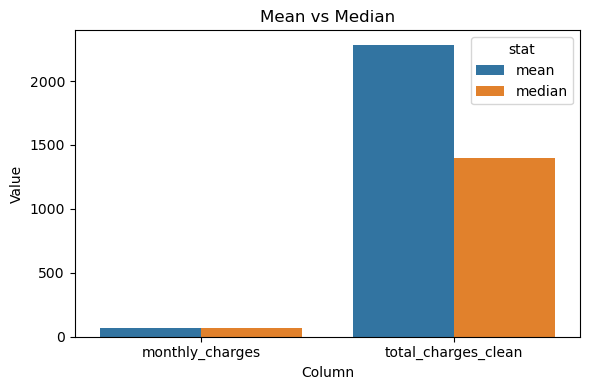

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['monthly_charges', 'total_charges_clean']

# 1. Compute mean and median
stats = (
    df[cols]
    .agg(['mean', 'median'])
    .T  # rows = columns, cols = ['mean','median']
    .reset_index()
    .rename(columns={'index': 'column'})
)

print(stats)

# 2. Plot mean vs median side by side
plt.figure(figsize=(6, 4))
stats_melted = stats.melt(id_vars='column', value_vars=['mean', 'median'],
                          var_name='stat', value_name='value')

sns.barplot(data=stats_melted, x='column', y='value', hue='stat')
plt.title('Mean vs Median')
plt.ylabel('Value')
plt.xlabel('Column')
plt.tight_layout()
plt.show()

In [32]:
    summary_rows = []

    for col in numeric_cols_to_review:
        series = df[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = series[(series < lower_bound) | (series > upper_bound)].count()

        summary_rows.append({
            "column": col,
            "dtype": str(series.dtype),
            "missing_count": int(series.isna().sum()),
            "mean": round(series.mean(), 2),
            "median": round(series.median(), 2),
            "std": round(series.std(), 2),
            "min": round(series.min(), 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "max": round(series.max(), 2),
            "skew": round(series.skew(), 2),
            "outlier_count_iqr": int(outlier_count)
        })

In [33]:
summary_df = pd.DataFrame(summary_rows)
print(summary_df)

                column    dtype  missing_count      mean    median      std  \
0        tenure_months    int64              0     32.37     29.00    24.56   
1      monthly_charges  float64              0     64.76     70.35    30.09   
2  total_charges_clean  float64             11   2283.30   1397.47  2266.77   
3          churn_score    int64              0     58.70     61.00    21.53   
4                 cltv    int64              0   4400.30   4527.00  1183.06   
5             latitude  float64              0     36.28     36.39     2.46   
6            longitude  float64              0   -119.80   -119.73     2.16   
7             zip_code    int64              0  93521.96  93552.00  1865.79   

        min        q1        q3       max  skew  outlier_count_iqr  
0      0.00      9.00     55.00     72.00  0.24                  0  
1     18.25     35.50     89.85    118.75 -0.22                  0  
2     18.80    401.45   3794.74   8684.80  0.96                  0  
3      5.00 

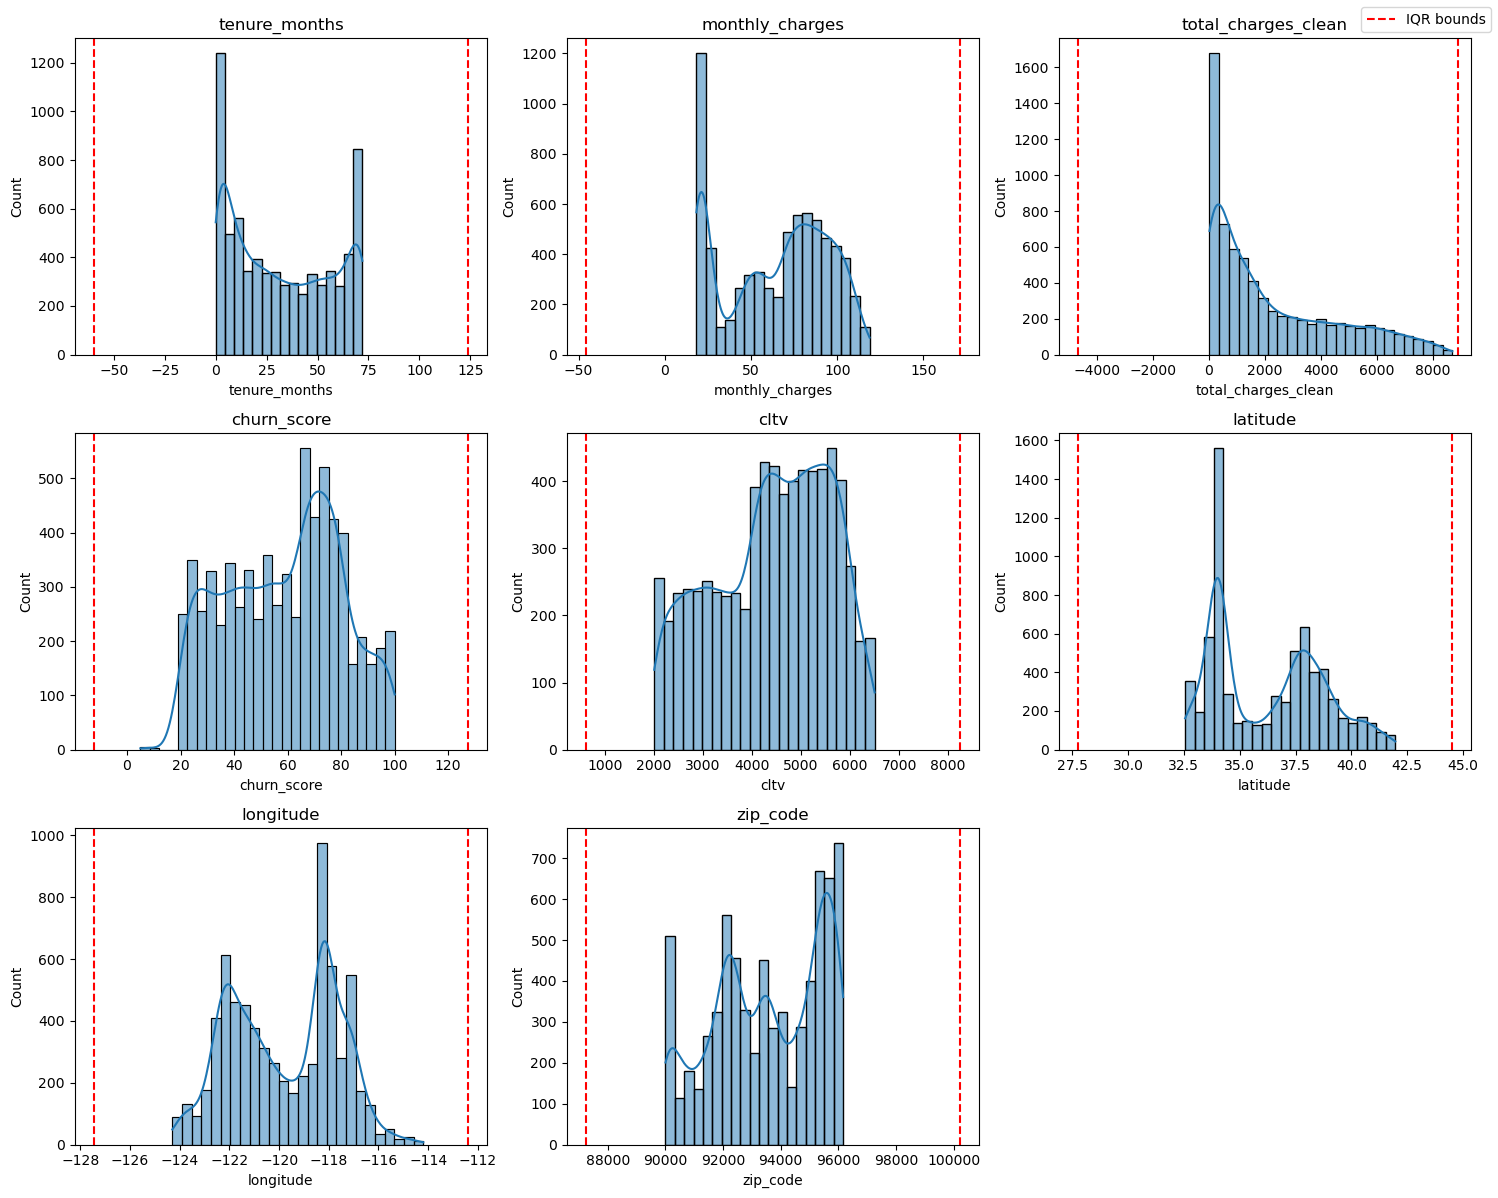

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = len(numeric_cols_to_review)
n_rows = math.ceil(n_cols / 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_to_review):
    series = df[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    ax = axes[i]
    sns.histplot(series, kde=True, ax=ax)
    ax.axvline(lower_bound, color='red', linestyle='--', label='IQR bounds' if i == 0 else "")
    ax.axvline(upper_bound, color='red', linestyle='--')
    ax.set_title(col)

# Handle legend only once
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper right')

# Hide extra axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

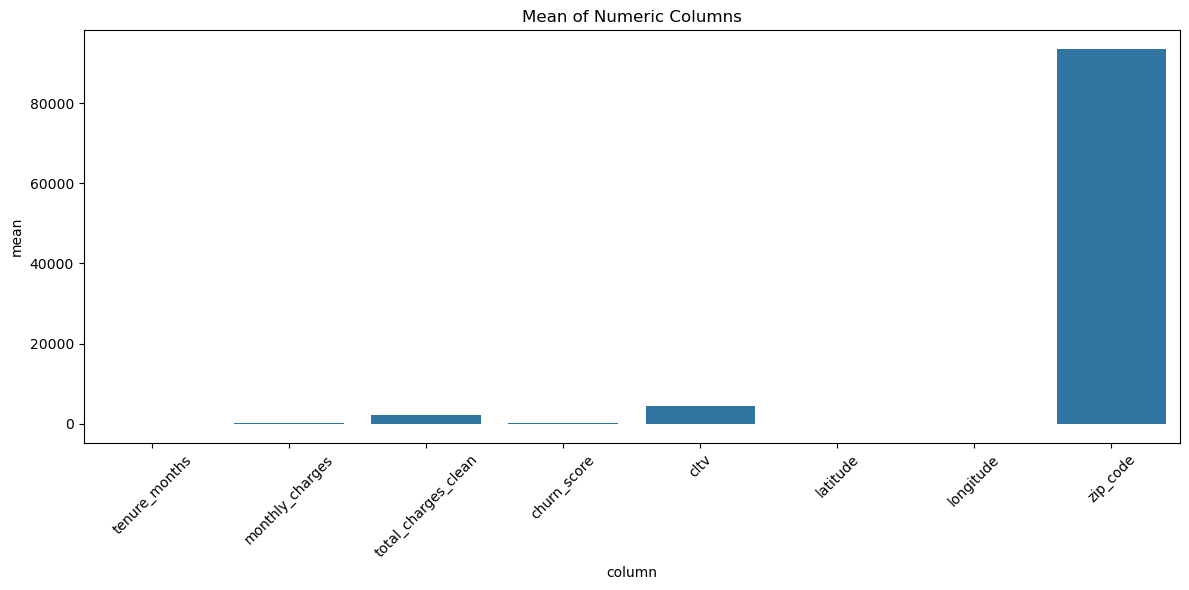

In [35]:
plt.figure(figsize=(12, 6))
sns.barplot(data=summary_df, x="column", y="mean")
plt.xticks(rotation=45)
plt.title("Mean of Numeric Columns")
plt.tight_layout()
plt.show()

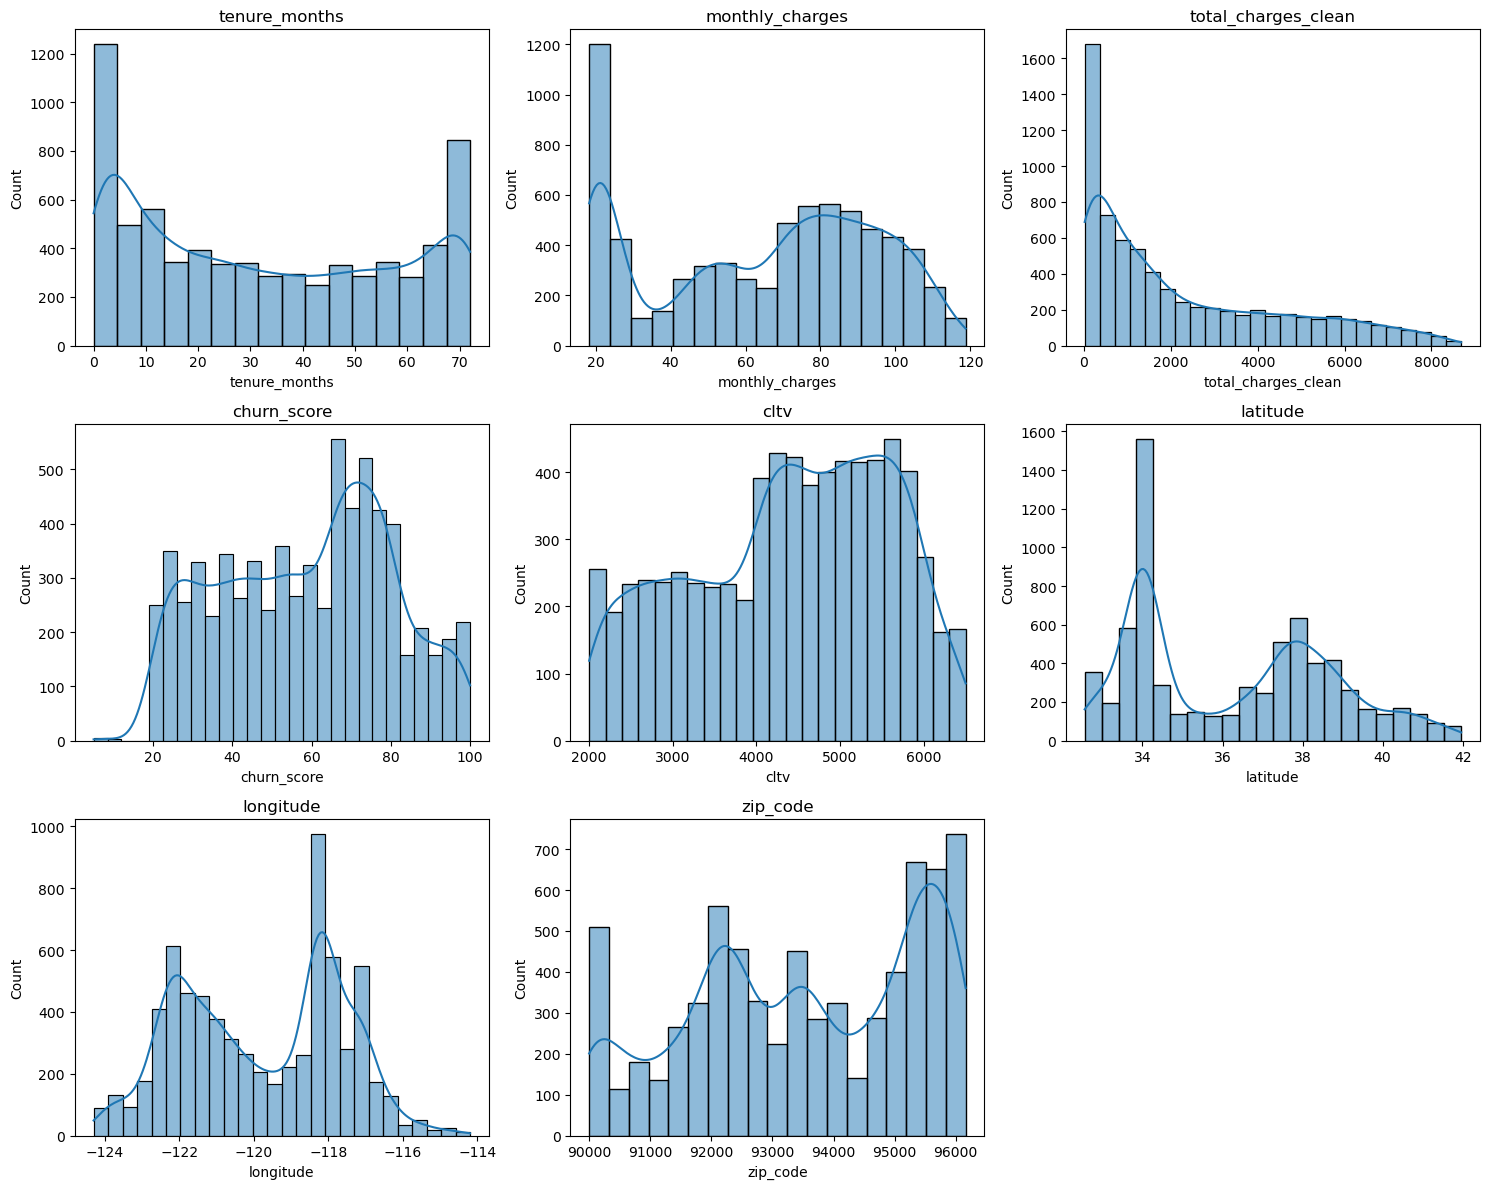

In [36]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = len(numeric_cols_to_review)
n_rows = math.ceil(n_cols / 3)

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols_to_review):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [37]:
for col in numeric_cols_to_review:
        print(f"\n--- {col} ---")
        print("Top 10 smallest values:")
        print(df[col].sort_values().head(10).tolist())
        print("Top 10 largest values:")
        print(df[col].sort_values(ascending=False).head(10).tolist())


--- tenure_months ---
Top 10 smallest values:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Top 10 largest values:
[72, 72, 72, 72, 72, 72, 72, 72, 72, 72]

--- monthly_charges ---
Top 10 smallest values:
[18.25, 18.4, 18.55, 18.7, 18.7, 18.75, 18.8, 18.8, 18.8, 18.8]
Top 10 largest values:
[118.75, 118.65, 118.6, 118.6, 118.35, 118.2, 117.8, 117.6, 117.5, 117.45]

--- total_charges_clean ---
Top 10 smallest values:
[18.8, 18.85, 18.85, 18.9, 19.0, 19.05, 19.1, 19.1, 19.1, 19.15]
Top 10 largest values:
[8684.8, 8672.45, 8670.1, 8594.4, 8564.75, 8547.15, 8543.25, 8529.5, 8496.7, 8477.7]

--- churn_score ---
Top 10 smallest values:
[5, 7, 7, 8, 8, 9, 9, 9, 20, 20]
Top 10 largest values:
[100, 100, 100, 100, 100, 100, 100, 100, 100, 100]

--- cltv ---
Top 10 smallest values:
[2003, 2003, 2003, 2004, 2004, 2004, 2006, 2007, 2007, 2007]
Top 10 largest values:
[6500, 6499, 6499, 6495, 6494, 6494, 6492, 6492, 6492, 6491]

--- latitude ---
Top 10 smallest values:
[32.555828, 32.555828, 32.555828, 32.555828,

In [38]:
if "tenure_months" in df.columns:
        print("Tenure = 0 count:", int((df["tenure_months"] == 0).sum()))
        print("Tenure <= 1 count:", int((df["tenure_months"] <= 1).sum()))

Tenure = 0 count: 11
Tenure <= 1 count: 624


In [39]:
if "monthly_charges" in df.columns:
        print("Monthly charges = 0 count:", int((df["monthly_charges"] == 0).sum()))

Monthly charges = 0 count: 0


In [40]:
if "total_charges_clean" in df.columns:
        print("Total charges = 0 count:", int((df["total_charges_clean"] == 0).sum()))
        print("Total charges missing count:", int(df["total_charges_clean"].isna().sum()))

Total charges = 0 count: 0
Total charges missing count: 11


## Lets review the categorical columns

In [41]:
categorical_cols_to_review = [
        "gender",
        "senior_citizen",
        "partner",
        "dependents",
        "phone_service",
        "multiple_lines",
        "internet_service",
        "online_security",
        "online_backup",
        "device_protection",
        "tech_support",
        "streaming_tv",
        "streaming_movies",
        "contract",
        "paperless_billing",
        "payment_method"
    ]

In [43]:
categorical_cols_to_review = [col for col in categorical_cols_to_review if col in df.columns]
target_col = "churn_value"



In [44]:
for feature in categorical_cols_to_review:
        print(f"\n\n===== {feature.upper()} =====")

        summary = (
            df.groupby(feature, dropna=False)
              .agg(
                  customer_count=(target_col, "size"),
                  churn_count=(target_col, "sum"),
                  churn_rate=(target_col, "mean")
              )
              .sort_values(by="customer_count", ascending=False)
        )

        summary["customer_pct"] = (summary["customer_count"] / len(df) * 100).round(2)
        summary["churn_rate"] = (summary["churn_rate"] * 100).round(2)
        summary["churn_pct_of_all_customers"] = (summary["churn_count"] / len(df) * 100).round(2)

        summary = summary[["customer_count", "customer_pct", "churn_count", "churn_rate", "churn_pct_of_all_customers"]]
        print(summary)



===== GENDER =====
        customer_count  customer_pct  churn_count  churn_rate  \
gender                                                          
Male              3555         50.48          930       26.16   
Female            3488         49.52          939       26.92   

        churn_pct_of_all_customers  
gender                              
Male                         13.20  
Female                       13.33  


===== SENIOR_CITIZEN =====
                customer_count  customer_pct  churn_count  churn_rate  \
senior_citizen                                                          
No                        5901         83.79         1393       23.61   
Yes                       1142         16.21          476       41.68   

                churn_pct_of_all_customers  
senior_citizen                              
No                                   19.78  
Yes                                   6.76  


===== PARTNER =====
         customer_count  customer_pct  churn_c

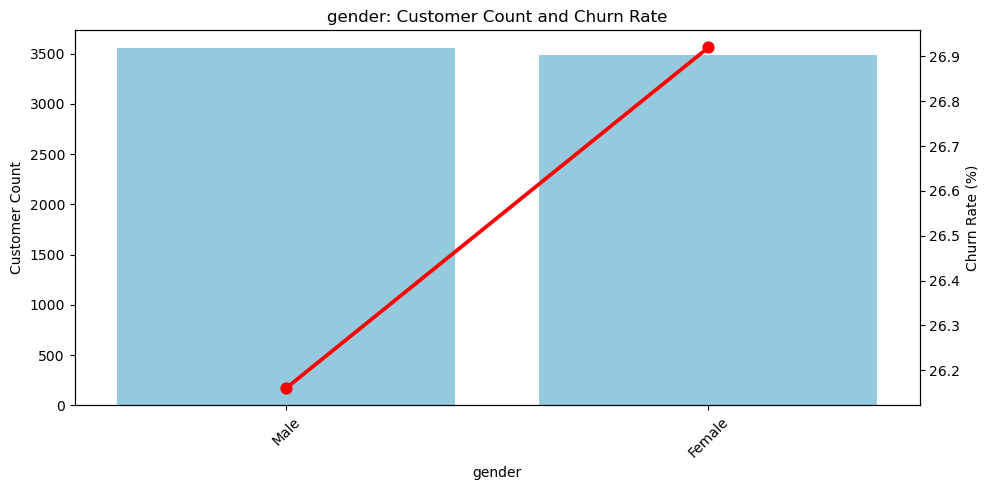

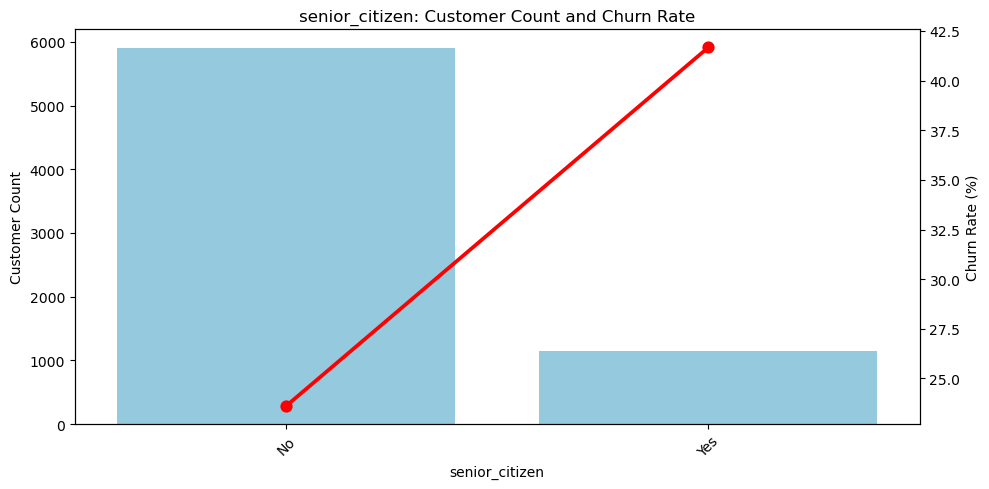

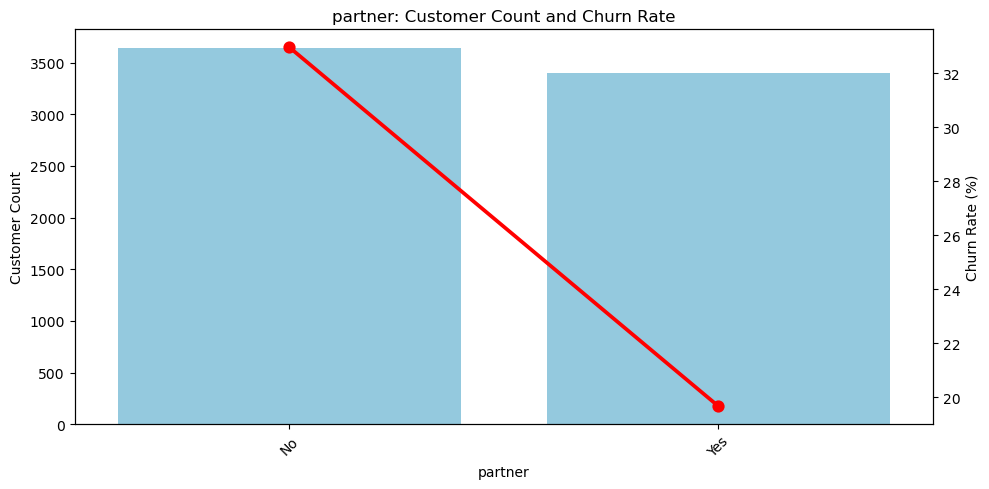

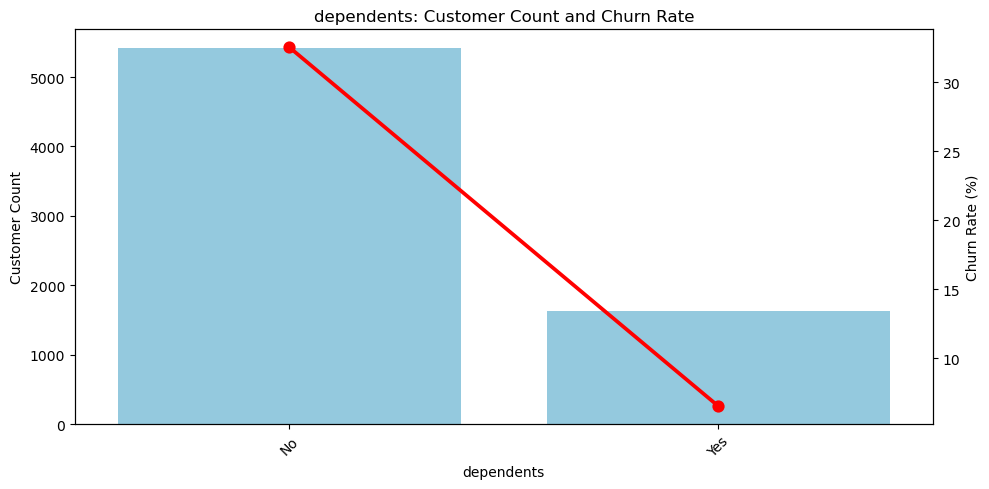

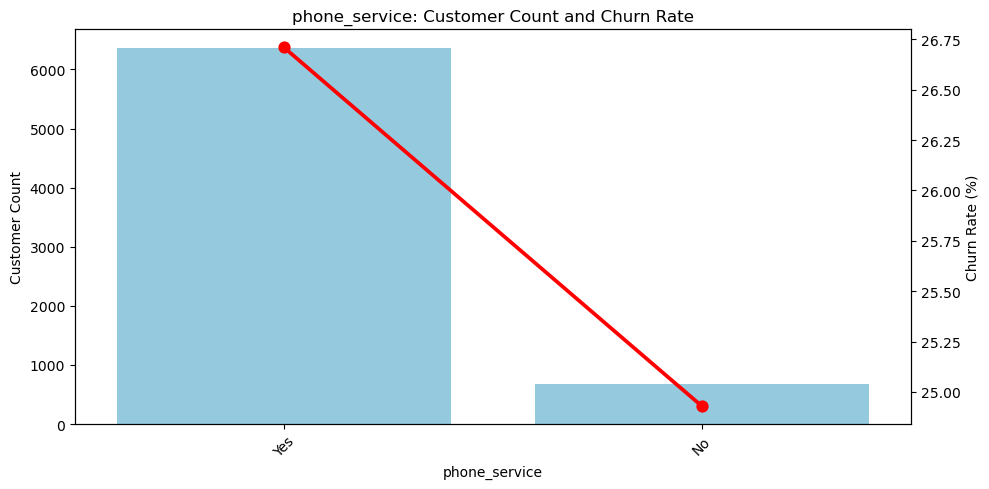

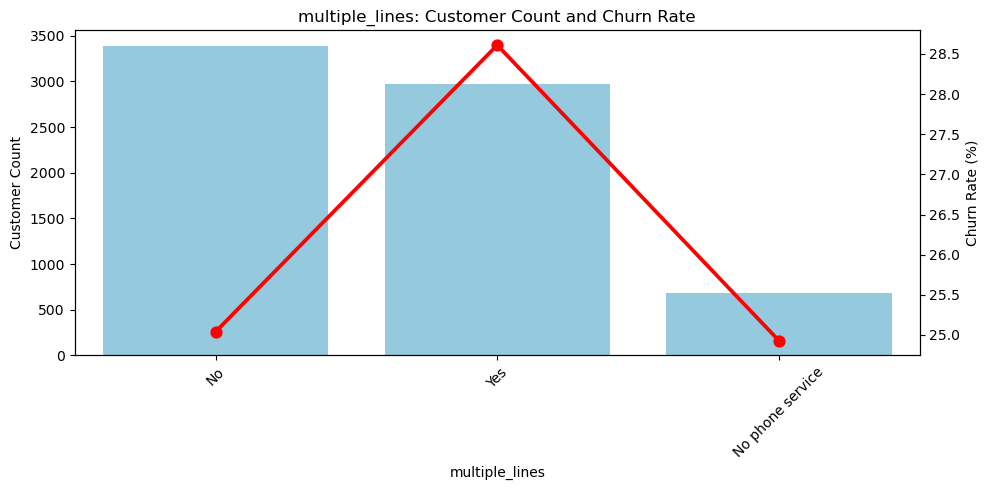

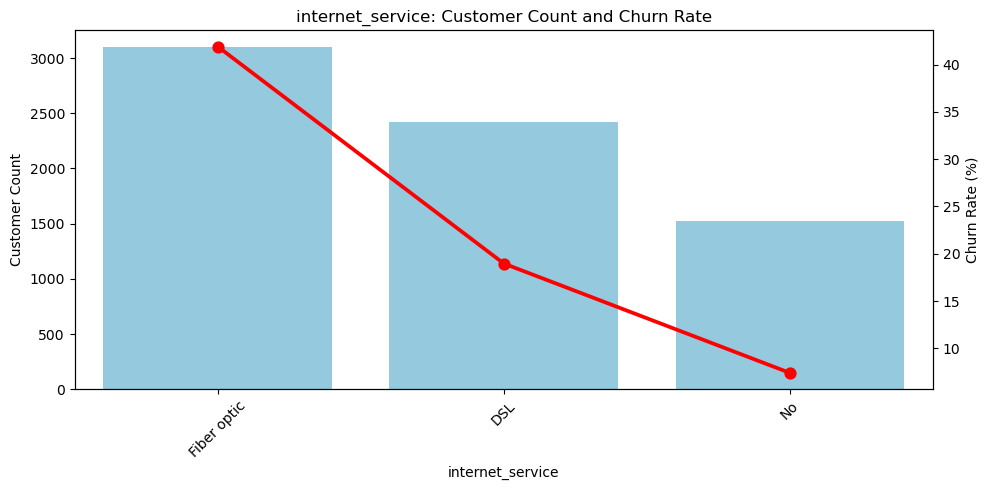

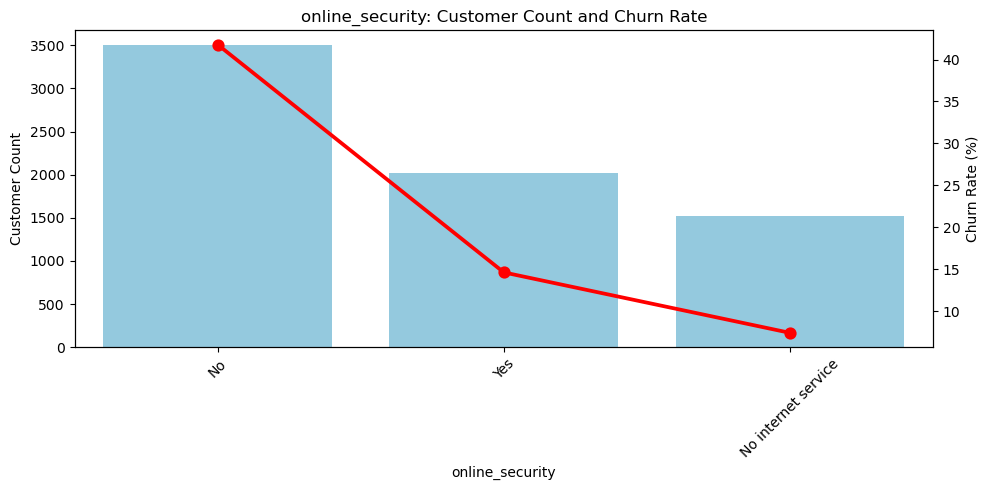

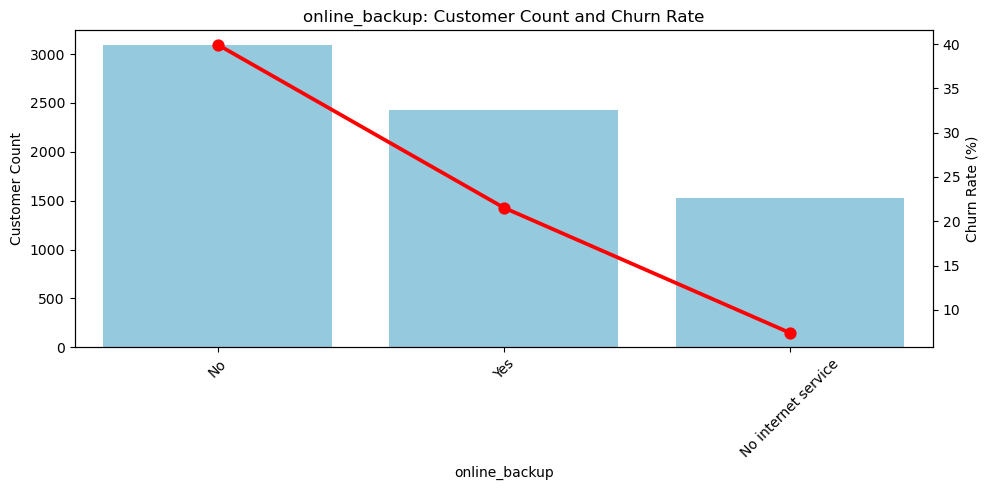

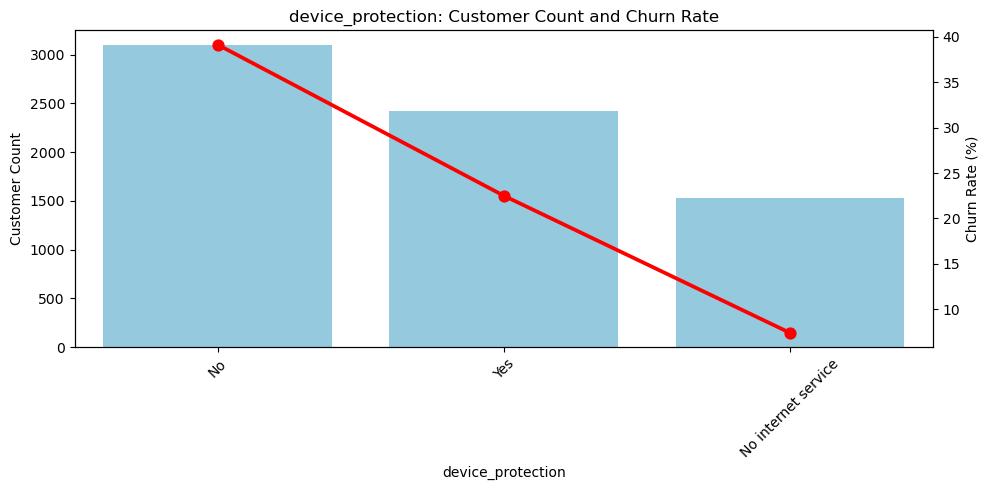

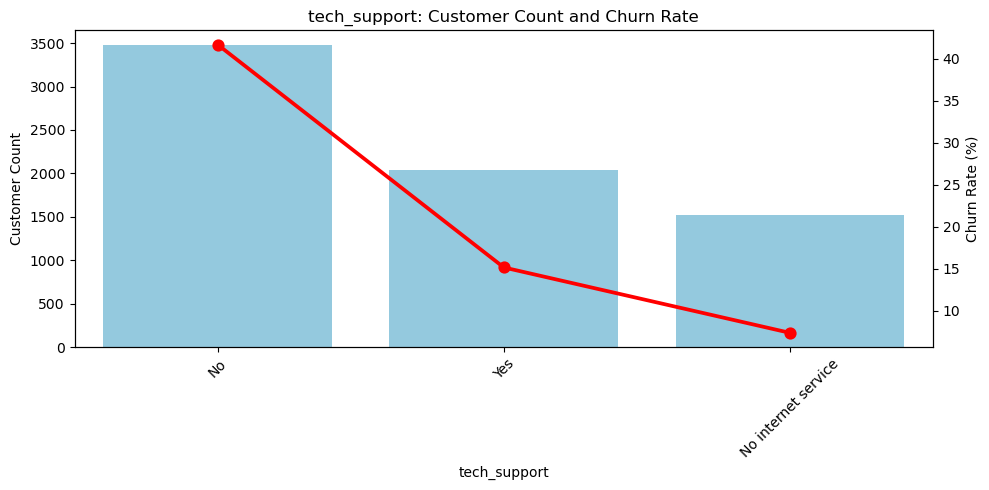

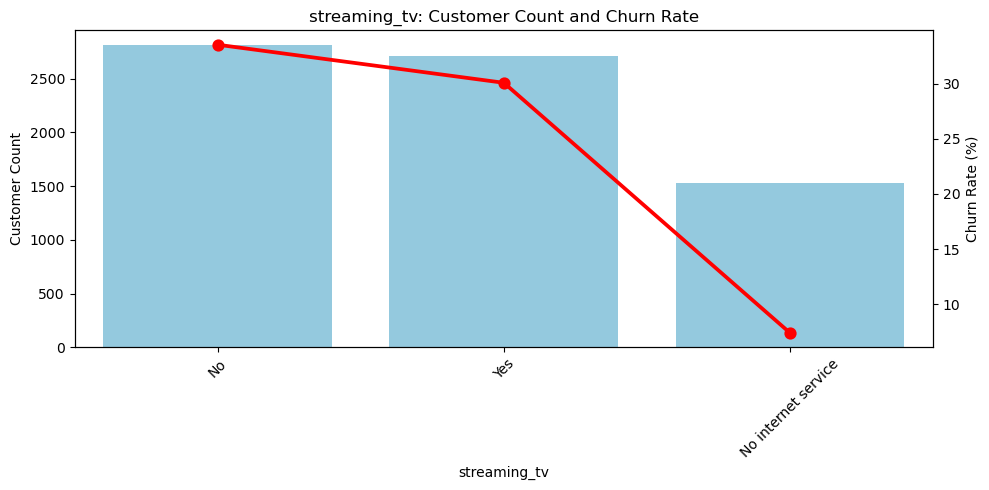

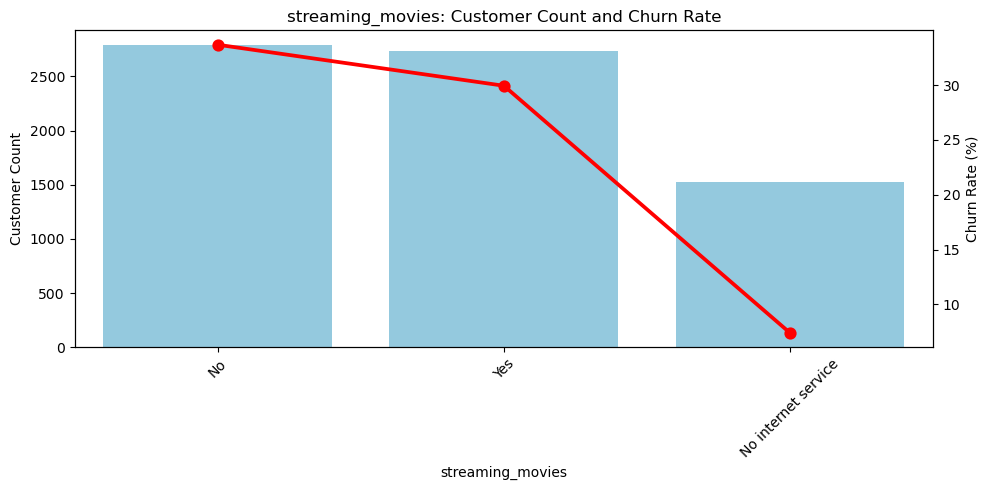

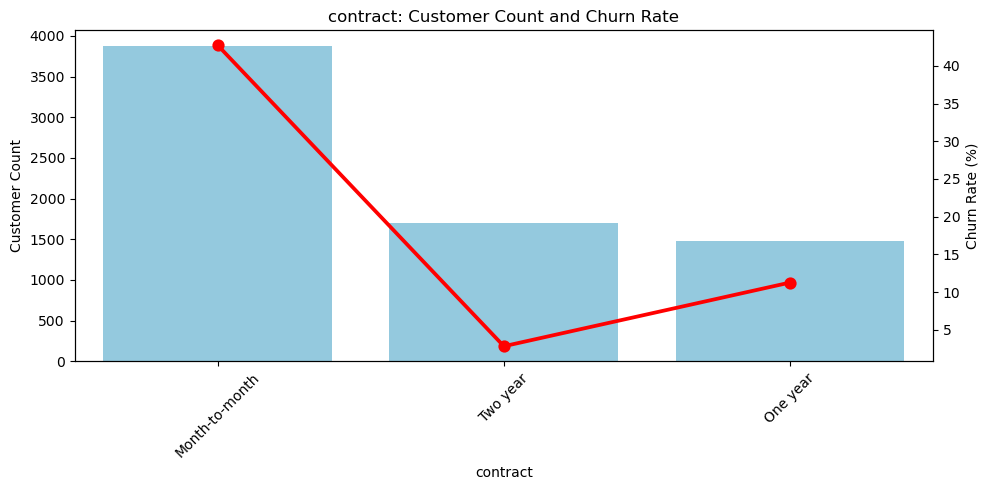

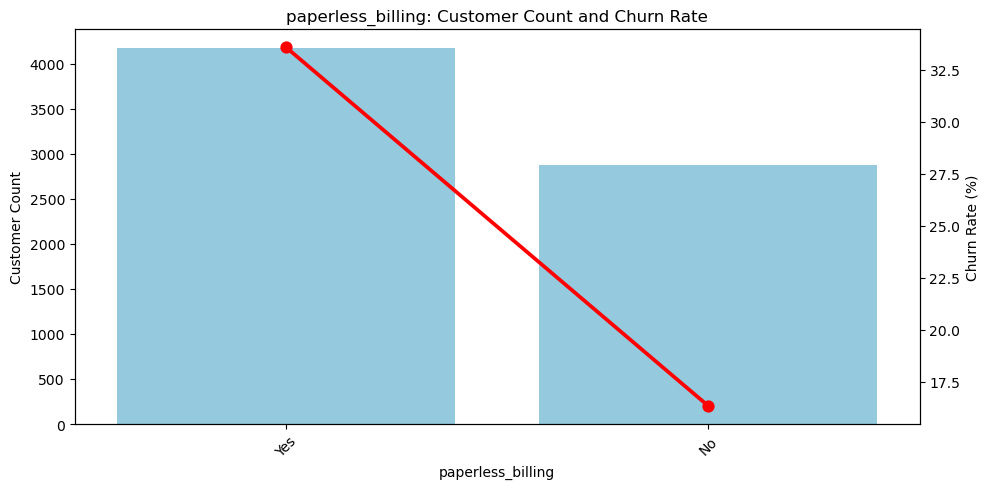

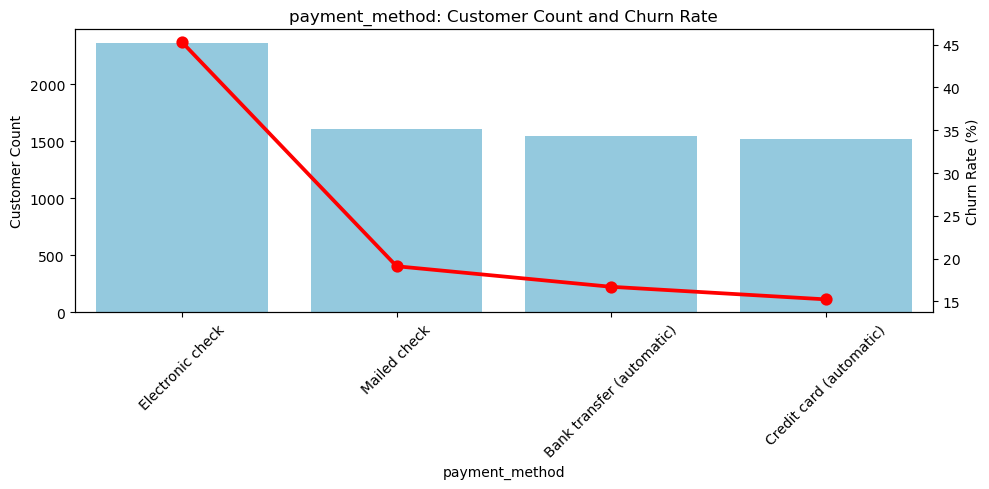

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

for feature in categorical_cols_to_review:
    summary = (
        df.groupby(feature, dropna=False)
          .agg(
              customer_count=(target_col, "size"),
              churn_count=(target_col, "sum"),
              churn_rate=(target_col, "mean")
          )
          .sort_values(by="customer_count", ascending=False)
    )

    summary["customer_pct"] = (summary["customer_count"] / len(df) * 100).round(2)
    summary["churn_rate"] = (summary["churn_rate"] * 100).round(2)  # now in %
    summary["churn_pct_of_all_customers"] = (summary["churn_count"] / len(df) * 100).round(2)

    # Optional: limit to top N categories if many levels
    top_n = 10
    summary_plot = summary.head(top_n).reset_index()

    # ---- Plot: bar for customer_count + line for churn_rate ----
    plt.figure(figsize=(10, 5))
    ax1 = sns.barplot(
        data=summary_plot,
        x=feature,
        y="customer_count",
        color="skyblue"
    )
    ax1.set_ylabel("Customer Count")
    ax1.set_xlabel(feature)
    ax1.tick_params(axis='x', rotation=45)

    # Second axis for churn rate
    ax2 = ax1.twinx()
    sns.pointplot(
        data=summary_plot,
        x=feature,
        y="churn_rate",
        color="red",
        ax=ax2
    )
    ax2.set_ylabel("Churn Rate (%)")

    plt.title(f"{feature}: Customer Count and Churn Rate")
    plt.tight_layout()
    plt.show()

In [47]:
    print("\n\n=== TOP CATEGORY LEVELS BY CHURN RATE (MIN 100 CUSTOMERS) ===")
    rows = []

    for feature in categorical_cols_to_review:
        tmp = (
            df.groupby(feature, dropna=False)
              .agg(customer_count=(target_col, "size"), churn_rate=(target_col, "mean"))
              .reset_index()
              .rename(columns={feature: "category"})
        )
        tmp = tmp[tmp["customer_count"] >= 100].copy()
        tmp["feature"] = feature
        tmp["churn_rate"] = (tmp["churn_rate"] * 100).round(2)
        rows.append(tmp[["feature", "category", "customer_count", "churn_rate"]])

    combined = pd.concat(rows, ignore_index=True)

    print("\nTop 15 highest churn-rate categories:")
    print(combined.sort_values(by="churn_rate", ascending=False).head(15))

    print("\nTop 15 lowest churn-rate categories:")
    print(combined.sort_values(by="churn_rate", ascending=True).head(15))



=== TOP CATEGORY LEVELS BY CHURN RATE (MIN 100 CUSTOMERS) ===

Top 15 highest churn-rate categories:
              feature          category  customer_count  churn_rate
41     payment_method  Electronic check            2365       45.29
34           contract    Month-to-month            3875       42.71
14   internet_service       Fiber optic            3096       41.89
16    online_security                No            3498       41.77
3      senior_citizen               Yes            1142       41.68
25       tech_support                No            3473       41.64
19      online_backup                No            3088       39.93
22  device_protection                No            3095       39.13
31   streaming_movies                No            2785       33.68
38  paperless_billing               Yes            4171       33.57
28       streaming_tv                No            2810       33.52
4             partner                No            3641       32.96
6          de

## Lets deep dive into the categorical columns and review the unique values with their relationship to the churn count.

In [49]:
    target_col = "churn_value"

    numeric_cols_to_compare = [
        "tenure_months",
        "monthly_charges",
        "total_charges_clean",
        "churn_score",
        "cltv"
    ]
    numeric_cols_to_compare = [col for col in numeric_cols_to_compare if col in df.columns]

In [50]:
    rows = []
    for col in numeric_cols_to_compare:
        grouped = df.groupby(target_col)[col]

        non_churn = df[df[target_col] == 0][col]
        churn = df[df[target_col] == 1][col]

        rows.append({
            "feature": col,
            "non_churn_mean": round(non_churn.mean(), 2),
            "churn_mean": round(churn.mean(), 2),
            "mean_diff_churn_minus_nonchurn": round(churn.mean() - non_churn.mean(), 2),
            "non_churn_median": round(non_churn.median(), 2),
            "churn_median": round(churn.median(), 2),
            "median_diff_churn_minus_nonchurn": round(churn.median() - non_churn.median(), 2),
            "non_churn_std": round(non_churn.std(), 2),
            "churn_std": round(churn.std(), 2),
            "missing_count": int(df[col].isna().sum())
        })

    summary_df = pd.DataFrame(rows)
    print(summary_df)   

               feature  non_churn_mean  churn_mean  \
0        tenure_months           37.57       17.98   
1      monthly_charges           61.27       74.44   
2  total_charges_clean         2555.34     1531.80   
3          churn_score           50.10       82.51   
4                 cltv         4490.92     4149.41   

   mean_diff_churn_minus_nonchurn  non_churn_median  churn_median  \
0                          -19.59             38.00         10.00   
1                           13.18             64.43         79.65   
2                        -1023.55           1683.60        703.55   
3                           32.41             50.00         82.00   
4                         -341.51           4620.00       4238.00   

   median_diff_churn_minus_nonchurn  non_churn_std  churn_std  missing_count  
0                            -28.00          24.11      19.53              0  
1                             15.22          31.09      24.67              0  
2                      

In [51]:
    print("\n=== DECILE-STYLE GROUP CHECKS FOR KEY NUMERIC FEATURES ===")
    key_cols = [col for col in ["tenure_months", "monthly_charges", "total_charges_clean"] if col in df.columns]

    for col in key_cols:
        print(f"\n--- {col} ---")

        temp = df[[col, target_col]].copy()
        temp = temp.dropna(subset=[col])

        try:
            temp["bin"] = pd.qcut(temp[col], q=10, duplicates="drop")
            decile_summary = temp.groupby("bin", observed=False).agg(
                customer_count=(target_col, "size"),
                churn_rate=(target_col, "mean")
            )
            decile_summary["churn_rate"] = (decile_summary["churn_rate"] * 100).round(2)
            print(decile_summary)
        except ValueError:
            print("Could not create quantile bins for this feature.")   


=== DECILE-STYLE GROUP CHECKS FOR KEY NUMERIC FEATURES ===

--- tenure_months ---
               customer_count  churn_rate
bin                                      
(-0.001, 2.0]             862       58.35
(2.0, 6.0]                619       45.40
(6.0, 12.0]               705       35.89
(12.0, 20.0]              692       30.92
(20.0, 29.0]              691       22.87
(29.0, 40.0]              717       21.90
(40.0, 50.0]              652       17.64
(50.0, 60.0]              698       13.61
(60.0, 69.0]              756        9.26
(69.0, 72.0]              651        3.53

--- monthly_charges ---
                 customer_count  churn_rate
bin                                        
(18.249, 20.05]             717        8.51
(20.05, 25.05]              703        9.82
(25.05, 45.85]              695       25.47
(45.85, 58.83]              702       24.50
(58.83, 70.35]              711       21.52
(70.35, 79.1]               700       38.14
(79.1, 85.5]                705     

In [52]:
    print("\n=== BUSINESS CHECK: TENURE BY CHURN ===")
    if "tenure_months" in df.columns:
        tenure_bins = pd.cut(
            df["tenure_months"],
            bins=[-1, 1, 6, 12, 24, 48, 72],
            labels=["0-1", "2-6", "7-12", "13-24", "25-48", "49-72"]
        )
        tenure_summary = df.groupby(tenure_bins, observed=False).agg(
            customer_count=(target_col, "size"), churn_rate=(target_col, "mean")
        )
        tenure_summary["churn_rate"] = (tenure_summary["churn_rate"] * 100).round(2)
        print(tenure_summary)


=== BUSINESS CHECK: TENURE BY CHURN ===
               customer_count  churn_rate
tenure_months                            
0-1                       624       60.90
2-6                       857       47.14
7-12                      705       35.89
13-24                    1024       28.71
25-48                    1594       20.39
49-72                    2239        9.51


In [54]:
    print("=== NUMERIC CORRELATION MATRIX ===")
    corr = df[numeric_cols].corr(numeric_only=True).round(3)
    print(corr)

=== NUMERIC CORRELATION MATRIX ===
                     count  zip_code  latitude  longitude  tenure_months  \
count                  NaN       NaN       NaN        NaN            NaN   
zip_code               NaN     1.000     0.896     -0.784          0.001   
latitude               NaN     0.896     1.000     -0.877         -0.002   
longitude              NaN    -0.784    -0.877      1.000         -0.002   
tenure_months          NaN     0.001    -0.002     -0.002          1.000   
monthly_charges        NaN    -0.005    -0.020      0.024          0.248   
churn_value            NaN     0.003    -0.003      0.005         -0.352   
churn_score            NaN    -0.003    -0.008      0.004         -0.225   
cltv                   NaN    -0.004     0.001      0.000          0.396   
total_charges_clean    NaN    -0.001    -0.010      0.009          0.826   

                     monthly_charges  churn_value  churn_score   cltv  \
count                            NaN          NaN      

In [55]:
    print("\n=== TOP ABSOLUTE CORRELATIONS AMONG NUMERIC FEATURES ===")
    corr_pairs = corr.abs().unstack().reset_index()
    corr_pairs.columns = ["feature_1", "feature_2", "abs_corr"]
    corr_pairs = corr_pairs[corr_pairs["feature_1"] != corr_pairs["feature_2"]]
    corr_pairs["pair_key"] = corr_pairs.apply(
        lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])), axis=1
    )
    corr_pairs = corr_pairs.drop_duplicates(subset="pair_key").drop(columns="pair_key")
    print(corr_pairs.sort_values(by="abs_corr", ascending=False).head(15))


=== TOP ABSOLUTE CORRELATIONS AMONG NUMERIC FEATURES ===
          feature_1            feature_2  abs_corr
12         zip_code             latitude     0.896
23         latitude            longitude     0.877
49    tenure_months  total_charges_clean     0.826
13         zip_code            longitude     0.784
67      churn_value          churn_score     0.665
59  monthly_charges  total_charges_clean     0.651
48    tenure_months                 cltv     0.396
46    tenure_months          churn_value     0.352
89             cltv  total_charges_clean     0.342
45    tenure_months      monthly_charges     0.248
47    tenure_months          churn_score     0.225
69      churn_value  total_charges_clean     0.199
56  monthly_charges          churn_value     0.193
57  monthly_charges          churn_score     0.134
68      churn_value                 cltv     0.127


In [56]:
dependency_checks = [
        ("internet_service", "online_security"),
        ("internet_service", "online_backup"),
        ("internet_service", "device_protection"),
        ("internet_service", "tech_support"),
        ("internet_service", "streaming_tv"),
        ("internet_service", "streaming_movies"),
        ("phone_service", "multiple_lines")
    ]

In [59]:
for parent_col, child_col in dependency_checks:
        if parent_col in df.columns and child_col in df.columns:
            print(f"\n--- {parent_col} vs {child_col} ---")
            print(pd.crosstab(df[parent_col], df[child_col]))


print("\n=== COMBINED BUSINESS PATTERN CHECKS ===")


--- internet_service vs online_security ---
online_security     No  No internet service   Yes
internet_service                                 
DSL               1241                    0  1180
Fiber optic       2257                    0   839
No                   0                 1526     0

--- internet_service vs online_backup ---
online_backup       No  No internet service   Yes
internet_service                                 
DSL               1335                    0  1086
Fiber optic       1753                    0  1343
No                   0                 1526     0

--- internet_service vs device_protection ---
device_protection    No  No internet service   Yes
internet_service                                  
DSL                1356                    0  1065
Fiber optic        1739                    0  1357
No                    0                 1526     0

--- internet_service vs tech_support ---
tech_support        No  No internet service   Yes
internet_service  

In [60]:
if {"contract", "paperless_billing", "churn_value"}.issubset(df.columns):
        print("\n--- contract vs paperless_billing (mean churn) ---")
        contract_paperless = pd.pivot_table(
            df,
            index="contract",
            columns="paperless_billing",
            values="churn_value",
            aggfunc="mean"
        )
        print((contract_paperless * 100).round(2))


--- contract vs paperless_billing (mean churn) ---
paperless_billing     No    Yes
contract                       
Month-to-month     31.50  48.30
One year            7.13  14.75
Two year            1.65   4.20


In [63]:
if {"internet_service", "contract", "churn_value"}.issubset(df.columns):
        print("\n--- internet_service vs contract (mean churn) ---")
        internet_contract = pd.pivot_table(
            df,
            index="internet_service",
            columns="contract",
            values="churn_value",
            aggfunc="mean"
        )
        print((internet_contract * 100).round(2))

if {"payment_method", "contract", "churn_value"}.issubset(df.columns):
        print("\n--- payment_method vs contract (mean churn) ---")
        payment_contract = pd.pivot_table(
            df,
            index="payment_method",
            columns="contract",
            values="churn_value",
            aggfunc="mean"
        )
        print((payment_contract * 100).round(2))


--- internet_service vs contract (mean churn) ---
contract          Month-to-month  One year  Two year
internet_service                                    
DSL                        32.22      9.30      1.91
Fiber optic                54.61     19.29      7.23
No                         18.89      2.47      0.78

--- payment_method vs contract (mean churn) ---
contract                   Month-to-month  One year  Two year
payment_method                                               
Bank transfer (automatic)           34.13      9.72      3.37
Credit card (automatic)             32.78     10.30      2.24
Electronic check                    53.73     18.44      7.74
Mailed check                        31.58      6.82      0.79
